<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%206%20-%20%20Seq2Seq/Seq2Seq_with_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 108.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [30]:
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import spacy
from datasets import load_dataset
import matplotlib.pyplot as plt

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
class Encoder(nn.Module):
  def __init__(self, input_size, embed_size, hidden_size, num_layers):
    super(Encoder, self).__init__()
    self.dropout = nn.Dropout(0.2)
    self.embedding = nn.Embedding(input_size, embed_size)
    self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, bidirectional=True, dropout=0.2)
    self.fc_hidden = nn.Linear(hidden_size*2, hidden_size)
    self.fc_cell = nn.Linear(hidden_size*2, hidden_size)
  def forward(self, x):
    x = self.embedding(x)
    x = self.dropout(x)
    states, (hidden, cell) = self.rnn(x)

    hidden = self.fc_hidden(torch.cat((hidden[0:1], hidden[1:2]), dim=2))
    cell = self.fc_cell(torch.cat((cell[0:1], cell[1:2]), dim=2))

    return states, hidden, cell


class Decoder(nn.Module):
  def __init__(self, input_size, embed_size, hidden_size, num_layers, output_size):
    super(Decoder, self).__init__()
    self.dropout = nn.Dropout(0.2)
    self.embedding = nn.Embedding(input_size, embed_size)
    self.rnn = nn.LSTM(hidden_size*2 + embed_size, hidden_size, num_layers, dropout=0.2)
    self.energy = nn.Linear(hidden_size*3, 1)
    self.softmax = nn.Softmax(dim=0)
    self.relu = nn.ReLU()
    self.fc = nn.Linear(hidden_size, output_size)
  def forward(self, x, states, hidden, cell):
    x = x.unsqueeze(0)
    x = self.embedding(x)
    x = self.dropout(x)

    seq_len = states.shape[0]
    h_reshaped = hidden.repeat(seq_len, 1, 1)
    energy = self.relu(self.energy(torch.cat((h_reshaped, states), dim=2)))
    attn = self.softmax(energy).permute(1, 2, 0)

    states_p = states.permute(1, 0, 2)
    context = torch.bmm(attn, states_p).permute(1, 0, 2)

    rnn_input = torch.cat((context, x), dim=2)
    outputs, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
    output = self.fc(outputs).squeeze(0)

    return output, hidden, cell

In [5]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[1]
        target_len = target.shape[0]
        target_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(target_len, batch_size, target_vocab_size).to(self.device)
        states, hidden, cell = self.encoder(source)

        x = target[0]
        for t in range(1, target_len):
            output, hidden, cell = self.decoder(x, states, hidden, cell)
            outputs[t] = output
            best_guess = output.argmax(1)
            x = target[t] if random.random() < teacher_forcing_ratio else best_guess

        return outputs

In [51]:
#dataset = load_dataset("bentrevett/multi30k")
#train_data, valid_data, test_data = dataset["train"], dataset["validation"], dataset["test"]

# Git can't load any pages that have loading bars used by these lines.

In [7]:
spacy_de = spacy.load("de_core_news_sm")
spacy_en = spacy.load("en_core_web_sm")


In [8]:
def tokenize_de(text):
    return [tok.text.lower() for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]


In [9]:
SPECIALS = ["<unk>", "<pad>", "<sos>", "<eos>"]

class Vocab:
    def __init__(self, counter, min_freq=2):
        self.itos = list(SPECIALS)
        for tok, freq in counter.items():
            if freq >= min_freq:
                self.itos.append(tok)
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def numericalize(self, tokens):
        unk = self.stoi["<unk>"]
        return [self.stoi.get(tok, unk) for tok in tokens]


In [10]:
def build_vocab(hf_split, field, tokenizer, min_freq=2):
    counter = Counter()
    for ex in hf_split:
        counter.update(tokenizer(ex[field]))
    return Vocab(counter, min_freq=min_freq)


In [11]:
src_vocab = build_vocab(train_data, "de", tokenize_de)
trg_vocab = build_vocab(train_data, "en", tokenize_en)


In [12]:
PAD_IDX = src_vocab.stoi["<pad>"]
SOS_IDX = src_vocab.stoi["<sos>"]
EOS_IDX = src_vocab.stoi["<eos>"]


In [13]:
len(src_vocab), len(trg_vocab)

(7853, 5893)

In [14]:
class TranslationDataset(Dataset):
    def __init__(self, hf_split, src_vocab, trg_vocab):
        self.data = hf_split
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        src_tokens = tokenize_de(ex["de"])
        trg_tokens = tokenize_en(ex["en"])
        src_ids = [SOS_IDX] + self.src_vocab.numericalize(src_tokens) + [EOS_IDX]
        trg_ids = [SOS_IDX] + self.trg_vocab.numericalize(trg_tokens) + [EOS_IDX]

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_ids, dtype=torch.long)

In [15]:
def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    trg_batch = pad_sequence(trg_batch, padding_value=PAD_IDX)
    return src_batch, trg_batch


In [16]:
train_ds = TranslationDataset(train_data, src_vocab, trg_vocab)
valid_ds = TranslationDataset(valid_data, src_vocab, trg_vocab)
test_ds = TranslationDataset(test_data, src_vocab, trg_vocab)


In [17]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [25]:
def train(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg)
        output_dim = output.shape[-1]
        output = output[1:].reshape(-1, output_dim)
        trg_flat = trg[1:].reshape(-1)
        loss = criterion(output, trg_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)
def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[1:].reshape(-1, output_dim)
            trg_flat = trg[1:].reshape(-1)
            loss = criterion(output, trg_flat)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)


In [19]:
INPUT_SIZE_ENC = len(src_vocab)
INPUT_SIZE_DEC = len(trg_vocab)
OUTPUT_SIZE = len(trg_vocab)

ENC_EMBED_SIZE = 300
DEC_EMBED_SIZE = 300
HIDDEN_SIZE = 512

In [22]:
import time

In [28]:
def train_model(EPOCHS):
  encoder = Encoder(INPUT_SIZE_ENC, ENC_EMBED_SIZE, HIDDEN_SIZE, 1).to(device)
  decoder = Decoder(INPUT_SIZE_DEC, DEC_EMBED_SIZE, HIDDEN_SIZE, 1, OUTPUT_SIZE).to(device)
  model = Seq2Seq(encoder, decoder, device).to(device)
  training_loss = []
  val_loss = []
  optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
  criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
  now = time.time()
  for epoch in range(EPOCHS):
      train_loss = train(model, train_loader, optimizer, criterion)
      valid_loss = evaluate(model, valid_loader, criterion)
      training_loss.append(train_loss)
      val_loss.append(valid_loss)

      print(f"Epoch {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}| Time: {(time.time()-now):.2f}")

  finish = time.time()-now
  min = finish // 60
  sec = finish % 60

  print(f"Model Trained for {EPOCHS} epochs and took {min} Minutes and {sec:.2f} Seconds!")
  return model, training_loss, valid_loss

In [29]:
model, training_loss, val = train_model(10)

Epoch 01 | Train Loss: 4.572 | Val Loss: 4.323| Time: 87.46
Epoch 02 | Train Loss: 3.795 | Val Loss: 3.980| Time: 166.00
Epoch 03 | Train Loss: 3.427 | Val Loss: 3.803| Time: 242.89
Epoch 04 | Train Loss: 3.167 | Val Loss: 3.705| Time: 320.42
Epoch 05 | Train Loss: 2.941 | Val Loss: 3.615| Time: 398.10
Epoch 06 | Train Loss: 2.772 | Val Loss: 3.586| Time: 475.26
Epoch 07 | Train Loss: 2.617 | Val Loss: 3.563| Time: 551.71
Epoch 08 | Train Loss: 2.487 | Val Loss: 3.520| Time: 630.26
Epoch 09 | Train Loss: 2.349 | Val Loss: 3.511| Time: 706.71
Epoch 10 | Train Loss: 2.228 | Val Loss: 3.482| Time: 788.19
Model Trained for 10 epochs and took 13.0 Minutes and 8.19 Seconds!


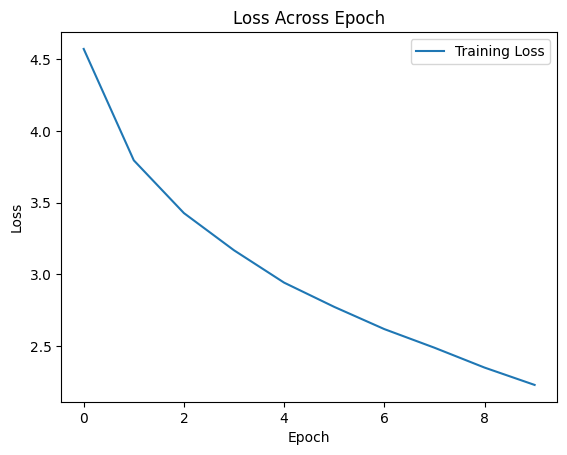

In [34]:
plt.plot(training_loss, label='Training Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Across Epoch")
plt.show()

In [52]:
torch.save(model.state_dict(), 'model.pt')

In [38]:
def translate_sentence(sentence, max_len=50):
    model.eval()
    if isinstance(sentence, str):
        tokens = tokenize_de(sentence)
    else:
        tokens = [tok.lower() for tok in sentence]

    src_ids = [SOS_IDX] + src_vocab.numericalize(tokens) + [EOS_IDX]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)

    with torch.inference_mode():
        states, hidden, cell = model.encoder(src_tensor)

    trg_indexes = [SOS_IDX]
    for _ in range(max_len):
        prev_token = torch.tensor([trg_indexes[-1]], dtype=torch.long).to(device)

        with torch.no_grad():
            output, hidden, cell = model.decoder(prev_token, states, hidden, cell)

        best_guess = output.argmax(1).item()
        trg_indexes.append(best_guess)

        if best_guess == EOS_IDX:
            break

    trg_tokens = [trg_vocab.itos[i] for i in trg_indexes]
    trg_tokens = [tok for tok in trg_tokens if tok not in ("<sos>", "<eos>")]

    return " ".join(trg_tokens)

In [43]:
translation_pairs = { # This dict was created using claude. I just asked it create a dictonary of german to english.
    "ein mann sitzt auf einer bank.": "a man is sitting on a bench.",
    "zwei frauen gehen die straße entlang.": "two women are walking down the street.",
    "ein hund läuft im park.": "a dog is running in the park.",
    "die kinder spielen im garten.": "the children are playing in the garden.",
    "ein mann fährt fahrrad.": "a man is riding a bicycle.",
    "die sonne scheint am himmel.": "the sun is shining in the sky.",
    "eine frau liest ein buch.": "a woman is reading a book.",
    "die katze schläft auf dem sofa.": "the cat is sleeping on the sofa.",
    "ein junge wirft einen ball.": "a boy is throwing a ball.",
    "die menschen warten auf den bus.": "the people are waiting for the bus.",
}


In [47]:
for key in translation_pairs:
  print(f"Model Prediciton: {translate_sentence(key)}| Actual Prediction: {translation_pairs[key]}")

Model Prediciton: a man sitting on a bench .| Actual Prediction: a man is sitting on a bench.
Model Prediciton: two women walking down the street .| Actual Prediction: two women are walking down the street.
Model Prediciton: a dog running in the park .| Actual Prediction: a dog is running in the park.
Model Prediciton: the children are playing in the yard .| Actual Prediction: the children are playing in the garden.
Model Prediciton: a man is riding a bicycle .| Actual Prediction: a man is riding a bicycle.
Model Prediciton: the sun is at the sky sky .| Actual Prediction: the sun is shining in the sky.
Model Prediciton: a woman reads a book book book .| Actual Prediction: a woman is reading a book.
Model Prediciton: the baby is sleeping on the couch .| Actual Prediction: the cat is sleeping on the sofa.
Model Prediciton: a boy is throwing a ball .| Actual Prediction: a boy is throwing a ball.
Model Prediciton: the people waiting waiting waiting waiting for the bus .| Actual Prediction:

In [50]:
# Works pretty well. Though in some cases it defitniely mess like in the last case. You can atleast see that the deeper meaning of each sentence was maintained across translaiton vs actual.